# 78 — Seed offset attack

This notebook attacks the seed offset directly and asks a narrow question: does changing the frame-0 seed improve final fascicle-length parity against MATLAB?

To keep the experiment fast and targeted, it reuses notebook 77's saved persistent-KLT affine matrices, TimTrack alpha stream, and aponeurosis lines. That isolates the seed geometry from the rest of the pipeline.

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SCRIPT = ROOT / 'scripts' / 'evaluate_seed_offset_strategies.py'
OUT = ROOT / 'results' / 'notebook78_seed_offset_attack'
assert SCRIPT.exists(), SCRIPT
OUT.mkdir(parents=True, exist_ok=True)
print('Project root:', ROOT)
print('Script:', SCRIPT)
print('Output directory:', OUT)

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_seed_offset_strategies.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook78_seed_offset_attack


In [2]:
env = dict(os.environ)
env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
subprocess.run([sys.executable, str(SCRIPT)], cwd=ROOT, env=env, check=True)

# Notebook 78 — seed offset attack

Aligned 2666 MATLAB/Python samples with Python offset 1.

The notebook evaluates seed changes using notebook 77's saved persistent-KLT affine matrices, TimTrack alpha, and aponeurosis lines. This is valid because the tracker points/affines are independent of the chosen fascicle seed; the seed only determines the propagated segment geometry.

## Main findings

- Sweeping the frame-0 seed alpha over 16.5–19.1 deg does not improve final FL over the current autonomous seed. The best FL RMSE in that sweep is 2.0117 mm at alpha 17.6 deg; the current seed is 17.6 deg with FL RMSE 2.0117 mm.
- The oracle MATLAB raw frame-0 seed does not help final FL. It produces FL RMSE 2.0943 mm, worse than baseline.
- Uniform x translation of the frame-0 seed changes final FL much more than changing seed alpha. In the tested range, FL RMSE improves from 2.0117 mm at dx=0 to 1.9192 mm at dx=120 px, while ANG RMSE stays essentially flat.
- Matching the MATLAB frame-0 x_sup 

CompletedProcess(args=['/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_seed_offset_strategies.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook78_summary.md').read_text()))

alpha_sweep = pd.read_csv(OUT / 'seed_alpha_sweep_metrics.csv')
x_sweep = pd.read_csv(OUT / 'seed_x_translation_sweep_metrics.csv')
named_variants = pd.read_csv(OUT / 'named_seed_variant_metrics.csv')

display(Markdown('## Final FL metrics from alpha sweep'))
display(alpha_sweep[alpha_sweep['variable'] == 'FL'].sort_values('rmse').reset_index(drop=True))

display(Markdown('## Final FL metrics from x-translation sweep'))
display(x_sweep[x_sweep['variable'] == 'FL'].sort_values('dx_seed_px').reset_index(drop=True))

display(Markdown('## Named seed variants'))
display(named_variants.sort_values(['variable', 'rmse']).reset_index(drop=True))

# Notebook 78 — seed offset attack

Aligned 2666 MATLAB/Python samples with Python offset 1.

The notebook evaluates seed changes using notebook 77's saved persistent-KLT affine matrices, TimTrack alpha, and aponeurosis lines. This is valid because the tracker points/affines are independent of the chosen fascicle seed; the seed only determines the propagated segment geometry.

## Main findings

- Sweeping the frame-0 seed alpha over 16.5–19.1 deg does not improve final FL over the current autonomous seed. The best FL RMSE in that sweep is 2.0117 mm at alpha 17.6 deg; the current seed is 17.6 deg with FL RMSE 2.0117 mm.
- The oracle MATLAB raw frame-0 seed does not help final FL. It produces FL RMSE 2.0943 mm, worse than baseline.
- Uniform x translation of the frame-0 seed changes final FL much more than changing seed alpha. In the tested range, FL RMSE improves from 2.0117 mm at dx=0 to 1.9192 mm at dx=120 px, while ANG RMSE stays essentially flat.
- Matching the MATLAB frame-0 x_sup offset directly is not beneficial: the left-shift variant that matches MATLAB x_sup has FL RMSE 2.0273 mm, worse than baseline.

## Interpretation

- The observed raw seed-vs-MATLAB angle offset is not the lever that controls final FL parity here.
- Final FL is much more sensitive to how the seed anchors x through the propagated prior than to small seed-angle changes.
- Because even the oracle MATLAB raw seed does not improve FL, the remaining FL difference is unlikely to be solved by copying MATLAB's frame-0 seed geometry alone.
- The next target should be the x/length anchoring model downstream of the seed, not just autonomous seed-angle selection.

- Alpha sweep CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook78_seed_offset_attack/seed_alpha_sweep_metrics.csv`
- X-shift sweep CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook78_seed_offset_attack/seed_x_translation_sweep_metrics.csv`
- Named variants CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook78_seed_offset_attack/named_seed_variant_metrics.csv`
- Sweep plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook78_seed_offset_attack/seed_offset_sweeps_fl_rmse.png`


## Final FL metrics from alpha sweep

,alpha_deg,variable,bias,mae,rmse
0,17.6,FL,-1.808792,1.928121,2.011658
1,17.7,FL,-1.833378,1.932371,2.012706
2,17.5,FL,-1.783716,1.923659,2.012867
3,17.8,FL,-1.857478,1.938010,2.015908
4,17.4,FL,-1.758136,1.919010,2.016442
5,17.9,FL,-1.881123,1.945224,2.021156
6,17.3,FL,-1.732047,1.914573,2.022484
7,18.0,FL,-1.904307,1.954434,2.028345
8,17.2,FL,-1.705433,1.913471,2.031079
9,18.1,FL,-1.927047,1.965749,2.037357


## Final FL metrics from x-translation sweep

,dx_seed_px,variable,bias,mae,rmse
0,-30,FL,-1.833490,1.952869,2.037048
1,-20,FL,-1.825260,1.944618,2.028489
2,-10,FL,-1.817024,1.936364,2.020023
3,0,FL,-1.808792,1.928121,2.011658
4,10,FL,-1.800553,1.919875,2.003383
5,20,FL,-1.792321,1.911632,1.995209
6,30,FL,-1.784083,1.903392,1.987138
7,40,FL,-1.775851,1.895156,1.979164
8,50,FL,-1.767612,1.886920,1.971292
9,60,FL,-1.759372,1.878686,1.963525


## Named seed variants

,variant,variable,bias,mae,rmse
0,right_shift_plus_60px,ANG,1.034016,1.073844,1.166108
1,baseline_autonomous_seed,ANG,1.034019,1.073845,1.166108
2,left_shift_match_matlab_xsup,ANG,1.034019,1.073845,1.166108
3,right_shift_same_magnitude,ANG,1.034020,1.073846,1.166109
4,matlab_angle_nearest_frame0_candidate,ANG,1.127913,1.128884,1.221557
5,oracle_matlab_raw_seed,ANG,1.129905,1.130277,1.223334
6,right_shift_plus_60px,FL,-1.759372,1.878686,1.963525
7,right_shift_same_magnitude,FL,-1.793474,1.912789,1.996351
8,baseline_autonomous_seed,FL,-1.808792,1.928121,2.011658
9,left_shift_match_matlab_xsup,FL,-1.824106,1.943462,2.027298


## Seed sweep plot

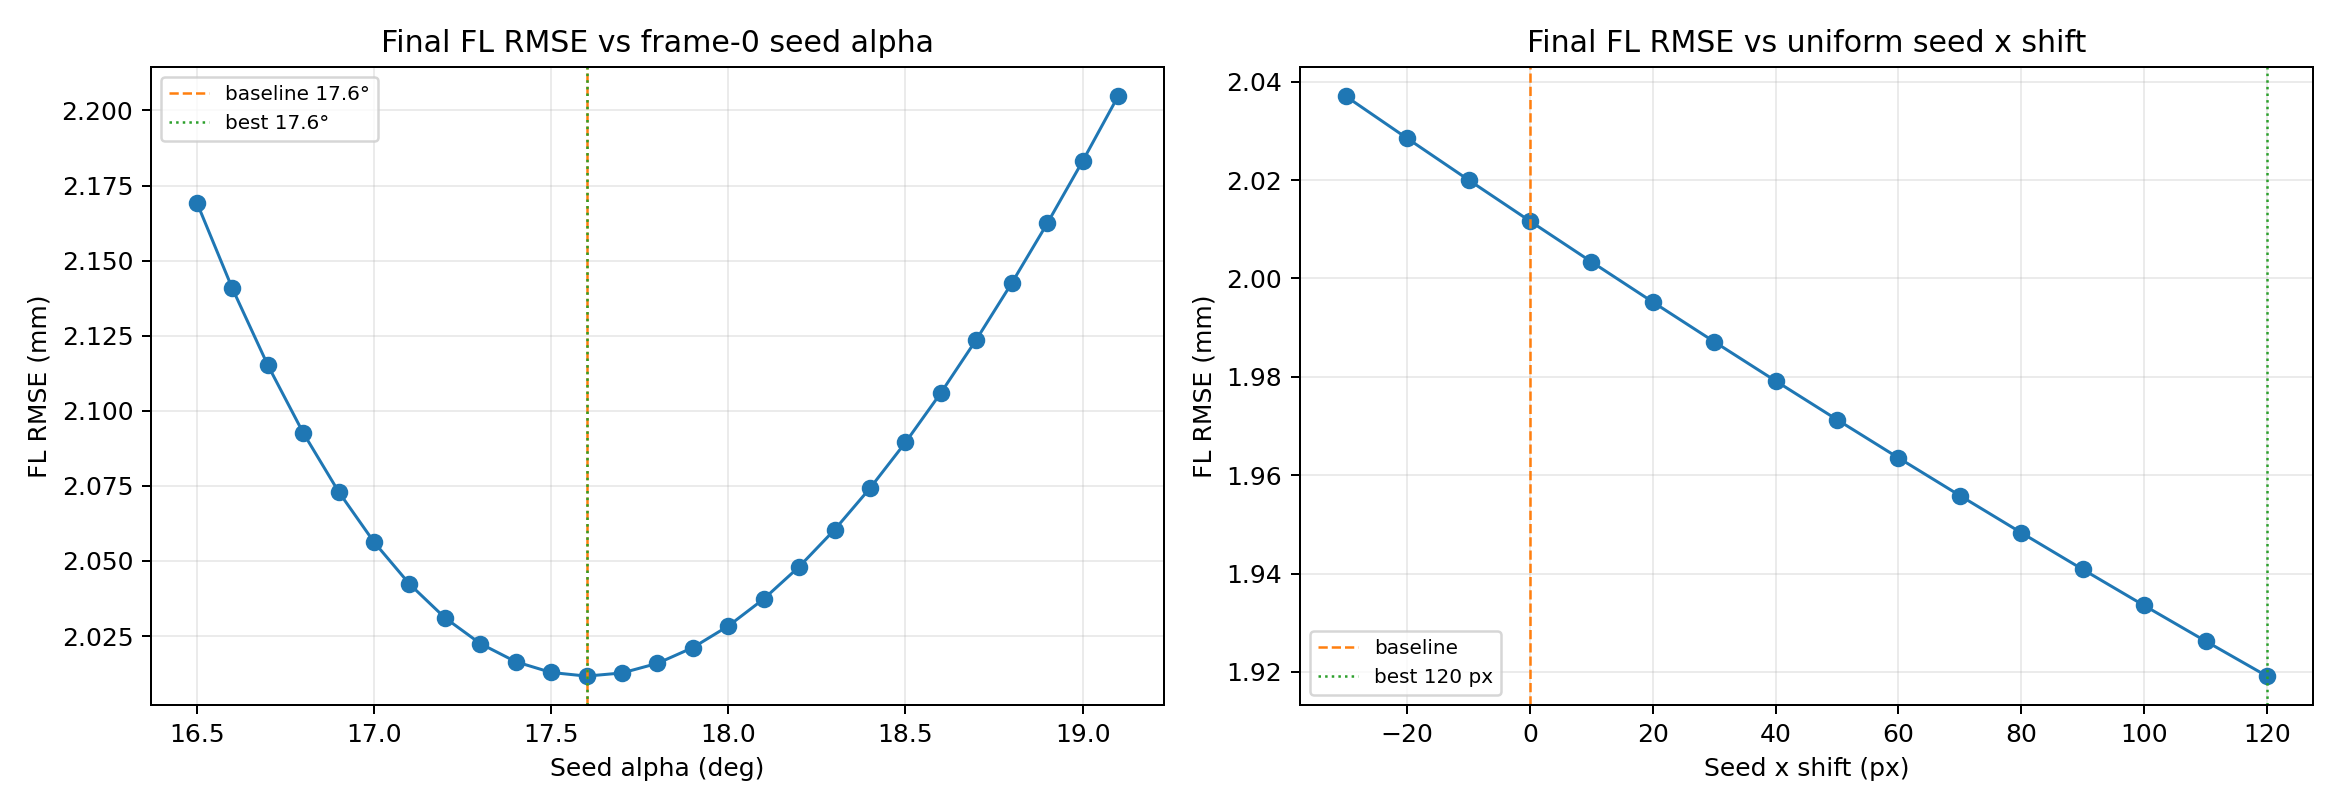

In [4]:
display(Markdown('## Seed sweep plot'))
display(Image(filename=str(OUT / 'seed_offset_sweeps_fl_rmse.png')))